In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn import tree

In [2]:
df=pd.read_csv('/content/heart.csv')

In [3]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


<Axes: >

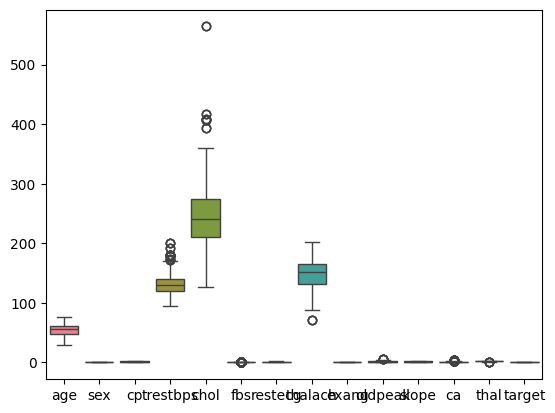

In [4]:
sns.boxplot(df)

In [5]:
n=df.select_dtypes(include=['number','float']).columns.tolist()
for i in n:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*(iqr)
  upper=q3+1.5*iqr
  df[i]=df[i].clip(upper,lower)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2.0,3.0,0
1,53,1,0,140,203,0,0,155,1,3.1,0,0.0,3.0,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0.0,3.0,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1.0,3.0,0
4,62,0,0,138,294,0,1,106,0,1.9,1,2.5,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0.0,2.0,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1.0,3.0,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1.0,2.0,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0.0,2.0,1


<Axes: >

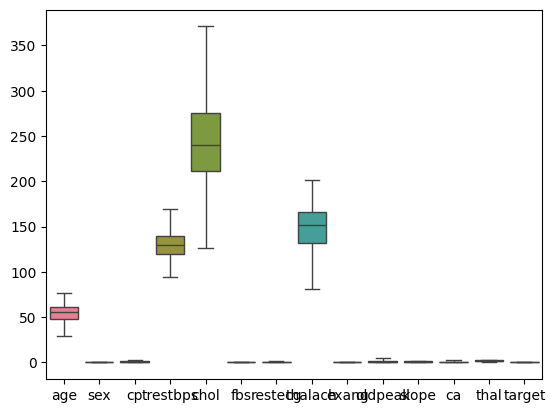

In [6]:
sns.boxplot(df)

In [7]:
x = df.drop('target', axis=1)

y = df['target']

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)


In [8]:
model = DecisionTreeClassifier()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.9853658536585366


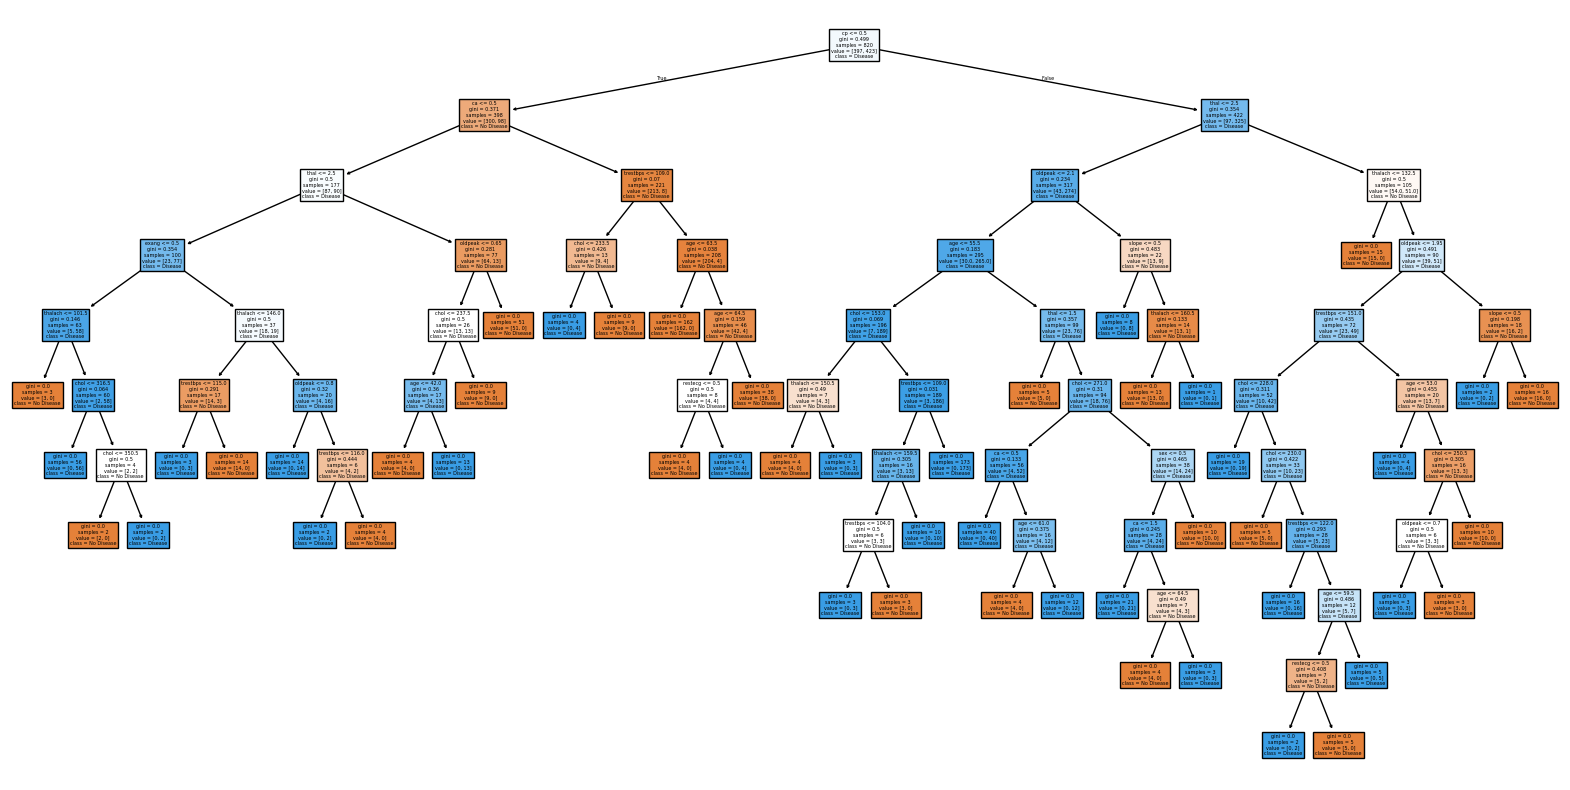

In [9]:
plt.figure(figsize=(20,10))
tree.plot_tree(model,feature_names=x.columns,class_names=['No Disease', 'Disease'],filled=True)
plt.show()

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print(accuracy_score(y_test, y_pred))

0.9853658536585366


In [11]:
from sklearn.svm import SVC

model_svm = SVC(random_state=42)
model_svm.fit(x_train, y_train)
y_pred_svm = model_svm.predict(x_test)

print(accuracy_score(y_test, y_pred_svm))

0.6780487804878049


In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn)}")

KNN Accuracy: 0.7365853658536585


In [13]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
y_pred_nb = nb_model.predict(x_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb)}")

Naive Bayes Accuracy: 0.8
